# Operadores inventados

En el presente _notebook_ se realiza la implementación de todos los operadores basados en información biológica que se proponen para el avance de este trabajo. Principalmente, se espera obtener un conjunto de ideas que el docente pueda evaluar y aportar retroalimentación previo a crear un conjunto de operadores refinados aceptables dentro de los alcances de este trabajo.

In [1]:
#######################################################
# MODULO DE IMPORTACIONES Y UTILIDADES BASE
# Se reutilizan los módulos ya construidos y validados en Notes_1-NSGA-II
# (codificación de soluciones, Xie-Beni, dominancia de Pareto), en lugar de
# duplicar su lógica, ya que esta iteración se enfoca en los operadores de
# búsqueda local.
#######################################################

############################
# Importaciones
############################
import sys                                                  # Ajuste de sys.path para importar los módulos de Source Code.
from pathlib import Path                                    # Aplicar un formato generalizado de direcciones en el script.
import numpy  as np                                         # Aplicación de operaciones matematicas eficientes.
import matplotlib.pyplot as plt                             # Creación de gráficos.

sys.path.append(str(Path.cwd().parent))                     # Source Code/ (un nivel sobre Investigation_Notes/).

# Obtención de código basada en el código fuente original.
import solution_encoding
from solution_encoding import (
    load_distance_matrix,
    random_medoids_pop,
    build_clusters_population,
    xie_beni
)
from pareto_sorting import non_dominated_sort, crowding_distance
from performance import (
    hypervolume_from_origin,
    plot_pareto_fronts,
    jaccard_population
)

def _dominates(obj_a, obj_b) -> bool:
    """
    Determina si la solución A domina a la solución B (minimización),
    según la definición (2) del paper:

        A ≺ B  ⟺  ∀t: P_t(A) ≤ P_t(B)  ∧  ∃t: P_t(A) < P_t(B)

    Parámetros
    ----------
    obj_a, obj_b : secuencias de floats (ej. (XBEB, XBBB)).
    """
    not_worse = all(a <= b for a, b in zip(obj_a, obj_b))
    strictly_better = any(a < b for a, b in zip(obj_a, obj_b))
    return not_worse and strictly_better

############################
# Constantes
############################
DE_DIR = Path.cwd().parent.parent / "Datasets" / "Matrices" / "A2_S_DE.csv"
DB_DIR = Path.cwd().parent.parent / "Datasets" / "Matrices" / "A2_S_DB.csv"


############################
# Funciones propias
############################
def evaluate_objectives(
    medoids: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
) -> tuple[float, float]:
    """
    Evalúa (XBEB, XBBB) para UNA única solución de medoides, envolviendo
    build_clusters_population + xie_beni (pensadas para poblaciones) para
    el caso de un solo individuo, que es lo que requieren MOPR y PLS.

    Nota
    ----
    Siguiendo la misma libertad de eficiencia adoptada en el NSGA-II
    (Notes_1), la asignación de clusters se calcula UNA vez con GE y se
    reutiliza para ambos índices Xie-Beni, en lugar de recalcularla también
    con BI como sugiere estrictamente la Tabla 1 del paper. Si se decide
    revertir esta libertad, basta con calcular una segunda asignación con
    build_clusters_population(bi_matrix, medoids[None, :])[0] y ajustar
    xie_beni para aceptar labels distintas por matriz.
    """
    labels = build_clusters_population(ge_matrix, medoids[None, :])[0]
    return xie_beni(ge_matrix, bi_matrix, medoids, labels)

def plot_pareto_fronts_note(
    objectives,
    fronts: list[list[int]],
    title: str = "Frentes de Pareto",
    max_fronts_highlighted: int = 5,
    ax: "plt.Axes | None" = None,
) -> "plt.Axes":
    """
    Versión ligera de la función de graficación de frentes de Pareto usada
    en Notes_1 (XBEB vs XBBB), sin la dependencia de librerías externas de
    diversidad (biocluster), ya que aquí solo se necesita inspección visual
    rápida de los operadores de búsqueda local.
    """
    objectives = np.asarray(objectives, dtype=np.float64)

    own_fig = ax is None
    if own_fig:
        _, ax = plt.subplots(figsize=(7, 5))

    cmap = plt.get_cmap("viridis")
    n_fronts = len(fronts)

    for rank, front in enumerate(fronts):
        pts = objectives[front]
        finite_mask = np.all(np.isfinite(pts), axis=1)
        pts_finite = pts[finite_mask]

        if len(pts_finite) == 0:
            continue

        color = cmap(rank / max(n_fronts - 1, 1))
        label = f"F{rank + 1}" if rank < max_fronts_highlighted else None

        ax.scatter(
            pts_finite[:, 0], pts_finite[:, 1],
            color=color, label=label,
            s=45, edgecolors="black", linewidths=0.5,
            zorder=n_fronts - rank,
        )

        if rank == 0 and len(pts_finite) > 1:
            order = np.argsort(pts_finite[:, 0])
            ax.plot(
                pts_finite[order, 0], pts_finite[order, 1],
                linestyle="--", color=color, alpha=0.6, zorder=0,
            )

    ax.set_xlabel("XBEB (Expresión)")
    ax.set_ylabel("XBBB (Biológico)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize="small", title="Frentes")
    ax.grid(alpha=0.3)
    if own_fig:
        ax.figure.tight_layout()

    return ax


[backend] CuPy detectado → operaciones vectorizadas en GPU.


## Bio-Counterweight search

En el desarrollo del _NSGA-II_ y sus operadores hay un elemento que constantemente se repite: **El modoide es quien guía la construcción de grupos usando de referencia la expresión génica** según las definiciones dadas en los trabajos actualmente revisados; sin embargo, hay una idea la cual constantemente pasa por mi mente ¿Qué tal si en los medoides formados dentro del operador de búsqueda local existe un individuo que provee una guía biológica para un vecindario?

Por lo anterior se construye _Bio-Counterweight search_ bajo el siguiente pseudocódigo:

FUNCIÓN BioCounterweightSearch(C, labels, D_EB, D_BB, p):
    # C      : solución — vector de K medoides (índices de gen, 0-based)
    # labels : partición ÚNICA n→{1..K} ya evaluada
    # D_EB, D_BB : matrices de distancia n×n, YA normalizadas en [0,1]
    # p      : percentil de vecindad (ej. 0.05 → 5% más cercanos)

    D_avg ← (D_EB + D_BB) / 2                              # sin normalización adicional
    excluir ← C                                             # TODOS los medoides actuales de la solución

    (XB_EB_0, XB_BB_0) ← xie_beni(D_EB, D_BB, C, labels)    # referencia de la solución actual
    aceptadas ← []

    PARA cada k EN {1, ..., K}:
        z_k ← C[k]
        C_k ← {i : labels[i] = k}

        SI |C_k| ≤ 1:  CONTINUAR                             # cluster trivial → se evita

        # --- Hub biológico: MINIMIZAR distancia media (D_BB es distancia) ---
        PARA cada g EN C_k \ {z_k}:
            prom_bio[g] ← (1/(|C_k|-1)) · Σ_{g'∈C_k, g'≠g} D_BB[g,g']
        z_bio ← argmin_g prom_bio[g]

        # --- Vecindarios por percentil sobre TODO el dataset, excluyendo C ---
        N_zk ← {i ∉ excluir : D_avg[z_k, i] ≤ Percentil_p(D_avg[z_k, · ∉ excluir])}

        SI z_bio = z_k:
            N_C ← N_zk                                       # misma ancla → mismo cálculo, sin caso especial
        SINO:
            N_zbio ← {i ∉ excluir : D_avg[z_bio, i] ≤ Percentil_p(D_avg[z_bio, · ∉ excluir])}
            N_C ← N_zk ∩ N_zbio
            SI N_C = ∅:
                N_C ← N_zbio                                 # respaldo: prioriza el ancla BIOLÓGICA

        # --- Evaluación y aceptación estricta ---
        PARA cada c EN N_C:
            C'      ← C con z_k reemplazado por c
            labels' ← ReasignarParticiónCompleta(D_EB, C')   # reconstrucción GLOBAL de clusters
            (XB_EB', XB_BB') ← xie_beni(D_EB, D_BB, C', labels')

            SI XB_EB' < XB_EB_0  Y  XB_BB' < XB_BB_0:
                aceptadas.append((C', labels', XB_EB', XB_BB'))

    RETORNAR aceptadas



In [2]:
#######################################################
# MODULO BIO-COUNTERWEIGHT SEARCH (BCS)
# Para cada medoide z_k de la solución se busca un "hub biológico" z_bio
# dentro de su propio cluster (el gen con menor distancia BI PROMEDIO al
# resto del cluster) y se explora el vecindario por percentil combinando
# ambas anclas (z_k y z_bio). Solo se aceptan reemplazos que MEJOREN
# estrictamente ambos índices Xie-Beni respecto a la solución original.
#######################################################

def _biological_hub(cluster_members: np.ndarray, zk: int, bi_matrix: np.ndarray) -> int:
    """
    Determina z_bio: el gen de C_k \\ {z_k} con menor distancia BI PROMEDIO
    al resto del cluster (bloque "Hub biológico" del pseudocódigo).
    """
    candidates = cluster_members[cluster_members != zk]
    prom_bio = np.array([
        bi_matrix[g, cluster_members[cluster_members != g]].mean()
        for g in candidates
    ])
    return int(candidates[np.argmin(prom_bio)])


def _percentile_neighborhood(
    anchor: int,
    d_avg: np.ndarray,
    excluir: set[int],
    p: float,
) -> set[int]:
    """
    N(ancla): índices fuera de `excluir` cuya distancia D_avg al ancla es
    menor o igual al percentil `p` de esas mismas distancias.
    """
    elegibles = np.array([i for i in range(d_avg.shape[0]) if i not in excluir])
    dists = d_avg[anchor, elegibles]
    umbral = np.percentile(dists, p * 100)
    return set(elegibles[dists <= umbral].tolist())


def bio_counterweight_search(
    C: np.ndarray,
    labels: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    p: float = 0.05,
    verbose: bool = False,
) -> list[dict]:
    """
    Bio-Counterweight search (BCS): para cada medoide z_k de C se determina
    un hub biológico z_bio dentro de su propio cluster y se explora el
    vecindario por percentil `p`, combinando ambas anclas (z_k, z_bio). Solo
    se aceptan reemplazos que mejoren estrictamente AMBOS índices Xie-Beni
    (XB_EB y XB_BB) respecto a la solución original.

    Parámetros
    ----------
    C          : np.ndarray (k,) — medoides de la solución actual.
    labels     : np.ndarray (n,) — partición ÚNICA ya evaluada (1-based,
                 mismo formato que build_clusters_population).
    ge_matrix, bi_matrix : matrices de distancia n×n, YA normalizadas en [0,1].
    p          : percentil de vecindad (ej. 0.05 → 5% más cercanos).

    Retorna
    -------
    list[dict] con llaves "solution", "labels", "xb_eb", "xb_bb" — una
    entrada por cada candidata ACEPTADA (puede quedar vacía).
    """
    K = len(C)
    d_avg = (ge_matrix + bi_matrix) / 2                      # Sin normalización adicional.
    excluir = set(C.tolist())                                # TODOS los medoides actuales de la solución.

    xb_eb_0, xb_bb_0 = xie_beni(ge_matrix, bi_matrix, C, labels)
    aceptadas: list[dict] = []

    for k in range(1, K + 1):
        zk = int(C[k - 1])
        cluster_members = np.where(labels == k)[0]

        if len(cluster_members) <= 1:
            continue                                          # Cluster trivial → se evita.

        # ── Hub biológico: minimiza la distancia BI promedio dentro de C_k ──
        z_bio = _biological_hub(cluster_members, zk, bi_matrix)

        # ── Vecindarios por percentil sobre TODO el dataset, excluyendo C ──
        N_zk = _percentile_neighborhood(zk, d_avg, excluir, p)

        if z_bio == zk:
            N_C = N_zk                                        # Misma ancla → mismo cálculo, sin caso especial.
        else:
            N_zbio = _percentile_neighborhood(z_bio, d_avg, excluir, p)
            N_C = N_zk & N_zbio
            if not N_C:
                N_C = N_zbio                                  # Respaldo: prioriza el ancla BIOLÓGICA.

        if verbose:
            print(f"[BCS] k={k}  z_k={zk}  z_bio={z_bio}  |N(C)|={len(N_C)}")

        # ── Evaluación y aceptación estricta ─────────────────────────────
        for c in N_C:
            C_prime = C.copy()
            C_prime[k - 1] = c
            labels_prime = build_clusters_population(ge_matrix, C_prime[None, :])[0]
            xb_eb_p, xb_bb_p = xie_beni(ge_matrix, bi_matrix, C_prime, labels_prime)

            if xb_eb_p < xb_eb_0 and xb_bb_p < xb_bb_0:
                aceptadas.append({
                    "solution": C_prime,
                    "labels": labels_prime,
                    "xb_eb": xb_eb_p,
                    "xb_bb": xb_bb_p,
                })

    return aceptadas


[load] 'A2_S_DE.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
[load] 'A2_S_DB.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.


n genes = 288  |  k medoides = 4  |  percentil p = 0.25

Soluciones al azar generadas: 9
F1 de la población (solo estas se exploran con BCS): 2



── Solución F1 0: ['GOLPH3L', 'ACADL', 'OVCH2', 'P2RY6'] ──
   XBEB_0=3.045236  XBBB_0=1.109237  |  candidatas aceptadas: 12
   Mejor candidata → ['GOLPH3L', 'ETV5', 'OVCH2', 'P2RY6']  (XBEB=0.643952, XBBB=1.088846)



── Solución F1 1: ['KCNA5', 'ANKRD61', 'SLC27A3', 'TARS1'] ──
   XBEB_0=0.706758  XBBB_0=1.148217  |  candidatas aceptadas: 16
   Mejor candidata → ['RARRES2', 'ANKRD61', 'SLC27A3', 'TARS1']  (XBEB=0.547547, XBBB=0.960538)

Llamadas a función objetivo consumidas: 365


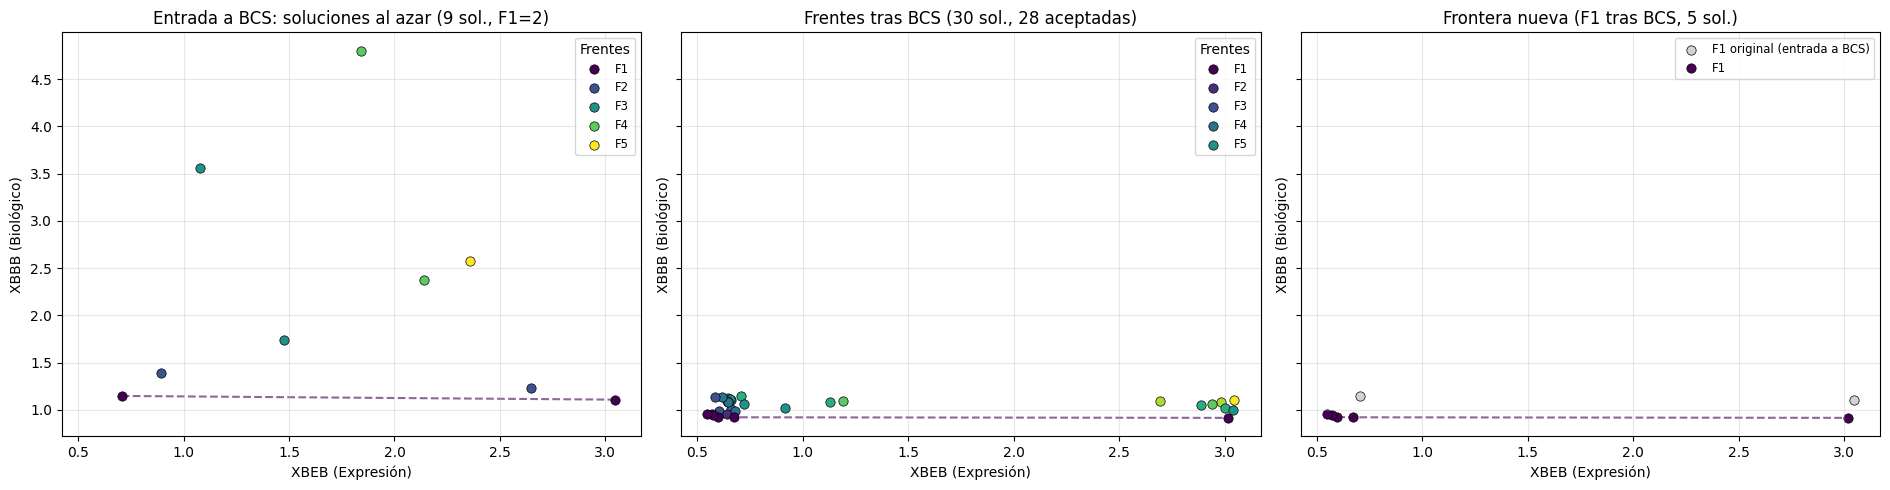

In [3]:
##################################
# Bloque de ejecución/testeo: BioCounterweightSearch
# (conjunto de soluciones al azar; BCS se aplica solo sobre su F1,
# igual que MOPR/PLS/MOLS operan sobre el F1 de Rv)
##################################
K         = 4
POP_SIZE  = 9
P         = 0.25
SEED      = None

ge_matrix, gene_names = load_distance_matrix(DE_DIR)
bi_matrix, _           = load_distance_matrix(DB_DIR)
n = ge_matrix.shape[0]

solution_encoding.OBJ_FUNCTION_CALLS = 0

test_solutions = random_medoids_pop(n=n, k=K, pop_size=POP_SIZE, seed=SEED)
test_objectives = np.array([evaluate_objectives(C, ge_matrix, bi_matrix) for C in test_solutions])

entrada_fronts = non_dominated_sort(test_objectives)
f1_idx = entrada_fronts[0]
f1_solutions = test_solutions[f1_idx]
f1_objectives = test_objectives[f1_idx]

print(f"n genes = {n}  |  k medoides = {K}  |  percentil p = {P}\n")
print(f"Soluciones al azar generadas: {len(test_solutions)}")
print(f"F1 de la población (solo estas se exploran con BCS): {len(f1_solutions)}\n")

resultados_bcs = []   # Una entrada por solución de f1_solutions: lista de dicts "aceptadas".
for i, C in enumerate(f1_solutions):
    labels = build_clusters_population(ge_matrix, C[None, :])[0]
    xb_eb_0, xb_bb_0 = f1_objectives[i]

    aceptadas = bio_counterweight_search(C, labels, ge_matrix, bi_matrix, p=P, verbose=False)
    resultados_bcs.append(aceptadas)

    genes = [gene_names[g] for g in C]
    print(f"── Solución F1 {i}: {genes} ──")
    print(f"   XBEB_0={xb_eb_0:.6f}  XBBB_0={xb_bb_0:.6f}  |  candidatas aceptadas: {len(aceptadas)}")

    if aceptadas:
        mejor = min(aceptadas, key=lambda d: (d["xb_eb"], d["xb_bb"]))
        mejores_genes = [gene_names[g] for g in mejor["solution"]]
        print(f"   Mejor candidata → {mejores_genes}  "
              f"(XBEB={mejor['xb_eb']:.6f}, XBBB={mejor['xb_bb']:.6f})")
    print()

print(f"Llamadas a función objetivo consumidas: {solution_encoding.OBJ_FUNCTION_CALLS}")

##################################
# Gráficos: (1) soluciones de entrada al azar (con su F1 destacado),
# (2) frontera final (todos los rangos tras agregar lo aceptado por BCS) y
# (3) la frontera NUEVA aislada (solo el F1 resultante), comparada con el F1
# original de entrada
##################################
todos_los_objetivos = np.vstack(
    [f1_objectives] + [np.array([[d["xb_eb"], d["xb_bb"]] for d in acc]) for acc in resultados_bcs if acc]
)
final_fronts = non_dominated_sort(todos_los_objetivos)
nueva_frontera_idx = final_fronts[0]
nueva_frontera_obj = todos_los_objetivos[nueva_frontera_idx]

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharex=True, sharey=True)
plot_pareto_fronts_note(
    test_objectives, entrada_fronts,
    title=f"Entrada a BCS: soluciones al azar ({len(test_solutions)} sol., F1={len(f1_solutions)})",
    ax=axes[0],
)
plot_pareto_fronts_note(
    todos_los_objetivos, final_fronts,
    title=f"Frentes tras BCS ({todos_los_objetivos.shape[0]} sol., "
          f"{todos_los_objetivos.shape[0] - f1_objectives.shape[0]} aceptadas)",
    ax=axes[1],
)

axes[2].scatter(
    f1_objectives[:, 0], f1_objectives[:, 1],
    color="lightgray", s=45, edgecolors="black", linewidths=0.5,
    label="F1 original (entrada a BCS)", zorder=1,
)
plot_pareto_fronts_note(
    todos_los_objetivos, [nueva_frontera_idx],
    title=f"Frontera nueva (F1 tras BCS, {len(nueva_frontera_idx)} sol.)",
    ax=axes[2],
)
axes[2].legend(loc="best", fontsize="small")

fig.tight_layout()
plt.show()


## Operador Medoid-Based Search (MBS)

**Matriz de discrepancia.** Sean $S_{EB} = 1 - D_{EB}$ y $S_{BB} = 1 - D_{BB}$ las matrices de
similitud de expresión y biológica, respectivamente. Se define la discrepancia entre un par
de genes como:

$$
\Delta(i,j) = S_{EB}(i,j) - S_{BB}(i,j) \in [-1, 1]
$$

$\Delta \to -1$ indica alta relación biológica pese a baja relación de expresión;
$\Delta \to +1$, la relación inversa; $\Delta \approx 0$, concordancia entre ambos criterios.

**Transformación por régimen ($mode \in \{\texttt{bio}, \texttt{no\_discrepancy}, \texttt{expresion}\}$),
fijo por corrida:**

$$
D_{mode}(x,i) =
\begin{cases}
\Delta(x,i) + 1 & mode = \texttt{bio} \\[4pt]
1 - \Delta(x,i) & mode = \texttt{expresion} \\[4pt]
|\Delta(x,i)|   & mode = \texttt{no\_discrepancy}
\end{cases}
$$

**Vecindario de reemplazo.** Se reutiliza `build_clusters_population` sobre $D_{mode}$,
usando el vector de medoides actual $C$ como población de referencia. Para cada $z_k \in C$:

$$
\mathcal{N}(z_k) = \{ i : \text{nearest\_medoid}_{D_{mode}}(i) = z_k \} \setminus C
$$

**Aceptación.** Idéntica a Bio-Counterweight Search: un candidato $c \in \mathcal{N}(z_k)$
reemplaza a $z_k$ (con reconstrucción global de la partición vía $D_{EB}$) si y solo si
mejora estrictamente ambos objetivos de Xie-Beni.



In [4]:
#######################################################
# MODULO MEDOID-BASED SEARCH (MBS)
# Se construye una matriz de discrepancia Δ = S_EB - S_BB (con S = 1 - D)
# y, según el régimen `mode`, se transforma en una matriz de distancia
# D_mode sobre la cual se reutiliza build_clusters_population para definir
# el vecindario de reemplazo de cada medoide: los genes cuyo medoide más
# cercano (bajo D_mode) es z_k, excluyendo los medoides de la solución.
# La aceptación es idéntica a BCS (mejora estricta de ambos Xie-Beni).
#######################################################

MBS_MODES = ("bio", "no_discrepancy", "expresion")

def build_discrepancy_matrix(
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    mode: str,
) -> np.ndarray:
    """
    Construye D_mode a partir de Δ(i,j) = S_EB(i,j) - S_BB(i,j) ∈ [-1, 1],
    con S = 1 - D:

        bio             → Δ + 1     (cercanía = alta relación biológica pese a baja expresión)
        expresion       → 1 - Δ     (régimen inverso)
        no_discrepancy  → |Δ|       (cercanía = concordancia entre ambos criterios)
    """
    assert mode in MBS_MODES, f"mode debe ser uno de {MBS_MODES}."
    delta = (1.0 - ge_matrix) - (1.0 - bi_matrix)
    if mode == "bio":
        return delta + 1.0
    if mode == "expresion":
        return 1.0 - delta
    return np.abs(delta)


def medoid_based_search(
    C: np.ndarray,
    labels: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    mode: str = "bio",
    d_mode: np.ndarray | None = None,
    verbose: bool = False,
) -> list[dict]:
    """
    Medoid-Based Search (MBS): para cada medoide z_k de C, su vecindario
    N(z_k) son los genes cuyo medoide más cercano bajo D_mode es z_k
    (excluyendo los medoides de C). Cada candidato c ∈ N(z_k) reemplaza a
    z_k y se acepta solo si mejora estrictamente AMBOS índices Xie-Beni
    (partición reconstruida globalmente con D_EB).

    Parámetros
    ----------
    C          : np.ndarray (k,) — medoides de la solución actual.
    labels     : np.ndarray (n,) — partición ÚNICA ya evaluada (1-based).
    ge_matrix, bi_matrix : matrices de distancia n×n, YA normalizadas en [0,1].
    mode       : "bio" | "no_discrepancy" | "expresion" (fijo por corrida).
    d_mode     : np.ndarray | None — D_mode precalculada; si es None se
        construye aquí. Conviene precalcularla al aplicar el operador
        sobre varias soluciones, ya que no depende de C.

    Retorna
    -------
    list[dict] con llaves "solution", "labels", "xb_eb", "xb_bb" — una
    entrada por cada candidata ACEPTADA (puede quedar vacía).
    """
    if d_mode is None:
        d_mode = build_discrepancy_matrix(ge_matrix, bi_matrix, mode)

    K = len(C)
    excluir = set(C.tolist())

    xb_eb_0, xb_bb_0 = xie_beni(ge_matrix, bi_matrix, C, labels)
    aceptadas: list[dict] = []

    # Asignación de cada gen a su medoide más cercano bajo D_mode.
    labels_mode = build_clusters_population(d_mode, C[None, :])[0]

    for k in range(1, K + 1):
        zk = int(C[k - 1])
        N_zk = [int(i) for i in np.where(labels_mode == k)[0] if int(i) not in excluir]

        if verbose:
            print(f"[MBS-{mode}] k={k}  z_k={zk}  |N(z_k)|={len(N_zk)}")

        for c in N_zk:
            C_prime = C.copy()
            C_prime[k - 1] = c
            labels_prime = build_clusters_population(ge_matrix, C_prime[None, :])[0]
            xb_eb_p, xb_bb_p = xie_beni(ge_matrix, bi_matrix, C_prime, labels_prime)

            if xb_eb_p < xb_eb_0 and xb_bb_p < xb_bb_0:
                aceptadas.append({
                    "solution": C_prime,
                    "labels": labels_prime,
                    "xb_eb": xb_eb_p,
                    "xb_bb": xb_bb_p,
                })

    return aceptadas


[load] 'A2_S_DE.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
[load] 'A2_S_DB.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
n genes = 288  |  k medoides = 4

Soluciones al azar generadas: 9
F1 de la población (solo estas se exploran con MBS): 4

════════ MBS — mode = bio ════════


── Solución F1 0: ['NUP62CL', 'PSMD14', 'MMP28', 'TCAP'] ──
   XBEB_0=0.795780  XBBB_0=1.759639  |  candidatas aceptadas: 8
   Mejor candidata → ['NUP62CL', 'PSMD14', 'MMP28', 'DECR2']  (XBEB=0.758603, XBBB=1.609621)


── Solución F1 1: ['CHRNA5', 'SPATS2', 'KDELR3', 'MROH6'] ──
   XBEB_0=4.607012  XBBB_0=1.078267  |  candidatas aceptadas: 52
   Mejor candidata → ['CHRNA5', 'SPATS2', 'KLF13', 'MROH6']  (XBEB=0.751205, XBBB=1.068827)


── Solución F1 2: ['PRNP', 'LEMD1', 'DPP3', 'SLC39A8'] ──
   XBEB_0=0.820467  XBBB_0=1.204330  |  candidatas aceptadas: 9
   Mejor candidata → ['CEP295', 'LEMD1', 'DPP3', 'SLC39A8']  (XBEB=0.737840, XBBB=1.097354)


── Solución F1 3: ['PROK2', 'PTPRH', 'CTPS1', 'C2CD4A'] ──
   XBEB_0=1.320935  XBBB_0=1.167714  |  candidatas aceptadas: 26
   Mejor candidata → ['PROK2', 'PTPRH', 'CTPS1', 'MLLT1']  (XBEB=0.597252, XBBB=1.070878)

════════ MBS — mode = no_discrepancy ════════


...

── Solución F1 3: ['PROK2', 'PTPRH', 'CTPS1', 'C2CD4A'] ──
   XBEB_0=1.320935  XBBB_0=1.167714  |  candidatas aceptadas: 24
   Mejor candidata → ['PROK2', 'PTPRH', 'CTPS1', 'CTDSPL']  (XBEB=0.555016, XBBB=1.123188)

════════ MBS — mode = expresion ════════


── Solución F1 0: ['NUP62CL', 'PSMD14', 'MMP28', 'TCAP'] ──
   XBEB_0=0.795780  XBBB_0=1.759639  |  candidatas aceptadas: 71
   Mejor candidata → ['NUP62CL', 'PSMD14', 'MMP28', 'VGLL3']  (XBEB=0.583805, XBBB=1.654162)


── Solución F1 1: ['CHRNA5', 'SPATS2', 'KDELR3', 'MROH6'] ──
   XBEB_0=4.607012  XBBB_0=1.078267  |  candidatas aceptadas: 62
   Mejor candidata → ['CHRNA5', 'SPATS2', 'KDELR3', 'TMIE']  (XBEB=0.804690, XBBB=1.051154)


── Solución F1 2: ['PRNP', 'LEMD1', 'DPP3', 'SLC39A8'] ──
   XBEB_0=0.820467  XBBB_0=1.204330  |  candidatas aceptadas: 30
   Mejor candidata → ['PRNP', 'LEMD1', 'DPP3', 'ACADL']  (XBEB=0.639591, XBBB=1.179958)


── Solución F1 3: ['PROK2', 'PTPRH', 'CTPS1', 'C2CD4A'] ──
   XBEB_0=1.320935  XBBB_0=1.167714  |  candidatas aceptadas: 39
   Mejor candidata → ['PROK2', 'PTPRH', 'CTPS1', 'SLX4IP']  (XBEB=0.634741, XBBB=1.138011)

Llamadas a función objetivo consumidas: 3429


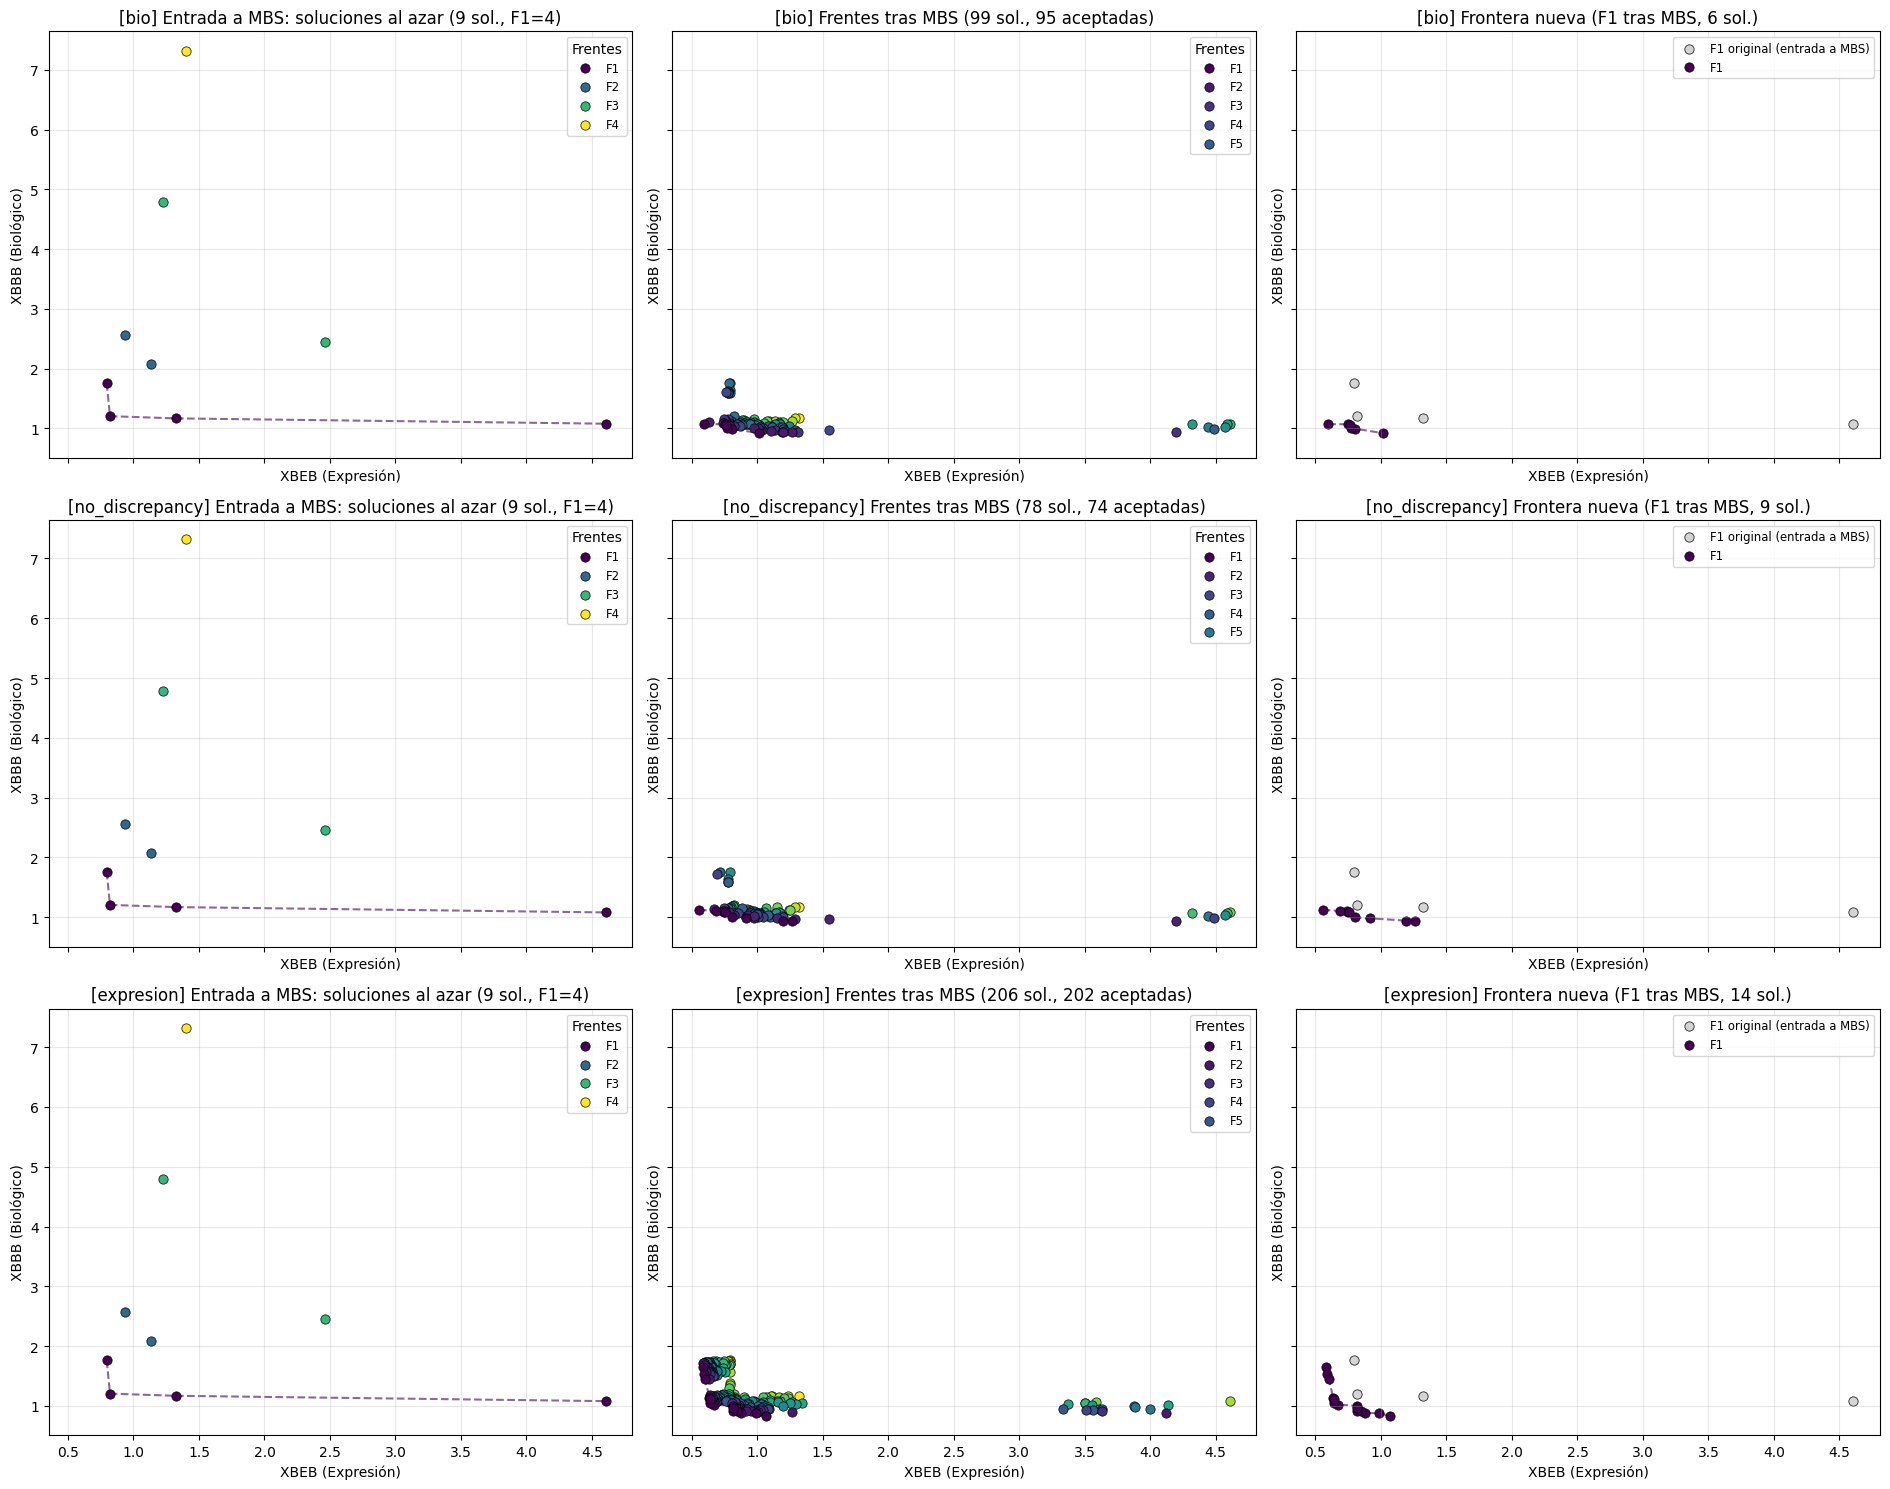

In [5]:
##################################
# Bloque de ejecución/testeo: Medoid-Based Search (MBS)
# (conjunto de soluciones al azar; MBS se aplica solo sobre su F1 y se
# prueba en los tres regímenes sobre la MISMA población para compararlos)
##################################
K         = 4
POP_SIZE  = 9
SEED      = None

ge_matrix, gene_names = load_distance_matrix(DE_DIR)
bi_matrix, _           = load_distance_matrix(DB_DIR)
n = ge_matrix.shape[0]

solution_encoding.OBJ_FUNCTION_CALLS = 0

test_solutions_mbs = random_medoids_pop(n=n, k=K, pop_size=POP_SIZE, seed=SEED)
test_objectives_mbs = np.array([evaluate_objectives(C, ge_matrix, bi_matrix) for C in test_solutions_mbs])

entrada_fronts_mbs = non_dominated_sort(test_objectives_mbs)
f1_idx_mbs = entrada_fronts_mbs[0]
f1_solutions_mbs = test_solutions_mbs[f1_idx_mbs]
f1_objectives_mbs = test_objectives_mbs[f1_idx_mbs]

print(f"n genes = {n}  |  k medoides = {K}\n")
print(f"Soluciones al azar generadas: {len(test_solutions_mbs)}")
print(f"F1 de la población (solo estas se exploran con MBS): {len(f1_solutions_mbs)}\n")

resultados_mbs = {}   # mode → lista (una entrada por solución del F1) de dicts "aceptadas".
for mode in MBS_MODES:
    d_mode = build_discrepancy_matrix(ge_matrix, bi_matrix, mode)     # No depende de C → 1 vez por modo.
    resultados_mbs[mode] = []

    print(f"════════ MBS — mode = {mode} ════════")
    for i, C in enumerate(f1_solutions_mbs):
        labels = build_clusters_population(ge_matrix, C[None, :])[0]
        xb_eb_0, xb_bb_0 = f1_objectives_mbs[i]

        aceptadas = medoid_based_search(C, labels, ge_matrix, bi_matrix, mode=mode, d_mode=d_mode)
        resultados_mbs[mode].append(aceptadas)

        genes = [gene_names[g] for g in C]
        print(f"── Solución F1 {i}: {genes} ──")
        print(f"   XBEB_0={xb_eb_0:.6f}  XBBB_0={xb_bb_0:.6f}  |  candidatas aceptadas: {len(aceptadas)}")

        if aceptadas:
            mejor = min(aceptadas, key=lambda d: (d["xb_eb"], d["xb_bb"]))
            mejores_genes = [gene_names[g] for g in mejor["solution"]]
            print(f"   Mejor candidata → {mejores_genes}  "
                  f"(XBEB={mejor['xb_eb']:.6f}, XBBB={mejor['xb_bb']:.6f})")
    print()

print(f"Llamadas a función objetivo consumidas: {solution_encoding.OBJ_FUNCTION_CALLS}")

##################################
# Gráficos (una fila por régimen): (1) soluciones de entrada al azar (con su
# F1 destacado), (2) frentes tras agregar lo aceptado por MBS y (3) la
# frontera NUEVA aislada, comparada con el F1 original de entrada
##################################
fig, axes = plt.subplots(len(MBS_MODES), 3, figsize=(19, 5 * len(MBS_MODES)), sharex=True, sharey=True)

for row, mode in enumerate(MBS_MODES):
    todos_los_objetivos_mbs = np.vstack(
        [f1_objectives_mbs]
        + [np.array([[d["xb_eb"], d["xb_bb"]] for d in acc]) for acc in resultados_mbs[mode] if acc]
    )
    final_fronts_mbs = non_dominated_sort(todos_los_objetivos_mbs)
    nueva_frontera_idx_mbs = final_fronts_mbs[0]

    plot_pareto_fronts_note(
        test_objectives_mbs, entrada_fronts_mbs,
        title=f"[{mode}] Entrada a MBS: soluciones al azar ({len(test_solutions_mbs)} sol., F1={len(f1_solutions_mbs)})",
        ax=axes[row, 0],
    )
    plot_pareto_fronts_note(
        todos_los_objetivos_mbs, final_fronts_mbs,
        title=f"[{mode}] Frentes tras MBS ({todos_los_objetivos_mbs.shape[0]} sol., "
              f"{todos_los_objetivos_mbs.shape[0] - f1_objectives_mbs.shape[0]} aceptadas)",
        ax=axes[row, 1],
    )
    axes[row, 2].scatter(
        f1_objectives_mbs[:, 0], f1_objectives_mbs[:, 1],
        color="lightgray", s=45, edgecolors="black", linewidths=0.5,
        label="F1 original (entrada a MBS)", zorder=1,
    )
    plot_pareto_fronts_note(
        todos_los_objetivos_mbs, [nueva_frontera_idx_mbs],
        title=f"[{mode}] Frontera nueva (F1 tras MBS, {len(nueva_frontera_idx_mbs)} sol.)",
        ax=axes[row, 2],
    )
    axes[row, 2].legend(loc="best", fontsize="small")

fig.tight_layout()
plt.show()


## consensus-based operator

FUNCIÓN ConsensusDivergenceSearch(F1_solutions, F1_labels, S_BB, D_EB, D_BB):

    M_F1 ← CoAsociación(F1_labels)
    Diff ← S_BB - M_F1

    candidatas ← []                                    # NO "nuevas_soluciones aceptadas": son candidatas

    PARA cada solución C EN F1_solutions:
        (xb_eb_0, xb_bb_0) ← xie_beni(D_EB, D_BB, C, labels_de_C)

        PARA cada medoide z_k EN C:
            C_k ← cluster de z_k bajo C
            excluir ← C ∪ C_k

            j* ← argmax_{j ∉ excluir} Diff(z_k, j)

            C'      ← C con z_k reemplazado por j*
            labels' ← ReasignarParticiónCompleta(D_EB, C')
            (xb_eb', xb_bb') ← xie_beni(D_EB, D_BB, C', labels')

            SI xb_eb' < xb_eb_0  O  xb_bb' < xb_bb_0:    # OR, no AND
                candidatas.append((C', labels'))

    RETORNAR candidatas   # se fusionan con Rv; la supervivencia la decide non_dominated_sort + crowding

In [6]:
#######################################################
# MODULO CONSENSUS DIVERGENCE SEARCH (CDS)
# A partir del F1 completo se construye la matriz de co-asociación M_F1
# (con qué frecuencia dos genes comparten cluster entre las soluciones del
# F1) y se contrasta con la similitud biológica: Diff = S_BB - M_F1 es alta
# donde dos genes están biológicamente relacionados pero el consenso del F1
# NO los agrupa. Cada medoide se reemplaza por el gen (fuera de su propio
# cluster y de C) que maximiza esa divergencia. A diferencia de BCS/MBS, el
# criterio es un OR (mejora en AL MENOS un objetivo): lo que se retorna son
# CANDIDATAS, no soluciones aceptadas; la supervivencia la decide luego
# non_dominated_sort + crowding al fusionarlas con Rv.
#######################################################

def co_association_matrix(labels_population: np.ndarray) -> np.ndarray:
    """
    M[i, j] = fracción de soluciones de `labels_population` (m, n) en las
    que los genes i y j quedan en el mismo cluster.
    """
    labels_population = np.asarray(labels_population)
    n = labels_population.shape[1]
    M = np.zeros((n, n), dtype=np.float64)
    for lab in labels_population:
        M += (lab[:, None] == lab[None, :])
    return M / labels_population.shape[0]


def consensus_divergence_search(
    F1_solutions: np.ndarray,
    F1_labels: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    verbose: bool = False,
) -> list[dict]:
    """
    Consensus Divergence Search (CDS): para cada solución C del F1 y cada
    medoide z_k de C, elige j* = argmax_{j ∉ C ∪ C_k} Diff(z_k, j), con
    Diff = S_BB - M_F1 (S_BB = 1 - D_BB), y genera C' reemplazando z_k por
    j* (partición reconstruida globalmente con D_EB). C' se conserva como
    candidata si mejora AL MENOS UNO de los dos objetivos (OR).

    Parámetros
    ----------
    F1_solutions : np.ndarray (m, k) — medoides de las soluciones del F1.
    F1_labels    : np.ndarray (m, n) — particiones (1-based) de esas
                   soluciones, ya evaluadas (mismo orden).
    ge_matrix, bi_matrix : matrices de distancia n×n, YA normalizadas en [0,1].

    Retorna
    -------
    list[dict] con llaves "solution", "labels", "xb_eb", "xb_bb" — una
    entrada por candidata (puede quedar vacía).
    """
    s_bb = 1.0 - bi_matrix
    diff = s_bb - co_association_matrix(F1_labels)

    candidatas: list[dict] = []

    for C, labels in zip(F1_solutions, F1_labels):
        xb_eb_0, xb_bb_0 = xie_beni(ge_matrix, bi_matrix, C, labels)

        for k in range(1, len(C) + 1):
            zk = int(C[k - 1])
            excluir = np.zeros(ge_matrix.shape[0], dtype=bool)
            excluir[C] = True                                  # C
            excluir[labels == k] = True                        # C_k

            scores = np.where(excluir, -np.inf, diff[zk])
            j_star = int(np.argmax(scores))
            if not np.isfinite(scores[j_star]):
                continue                                       # Sin genes elegibles.

            C_prime = C.copy()
            C_prime[k - 1] = j_star
            labels_prime = build_clusters_population(ge_matrix, C_prime[None, :])[0]
            xb_eb_p, xb_bb_p = xie_beni(ge_matrix, bi_matrix, C_prime, labels_prime)

            if verbose:
                print(f"[CDS] C={C.tolist()}  k={k}  z_k={zk} → j*={j_star}  "
                      f"Diff={scores[j_star]:.4f}  (XBEB={xb_eb_p:.4f}, XBBB={xb_bb_p:.4f})")

            if xb_eb_p < xb_eb_0 or xb_bb_p < xb_bb_0:         # OR, no AND.
                candidatas.append({
                    "solution": C_prime,
                    "labels": labels_prime,
                    "xb_eb": xb_eb_p,
                    "xb_bb": xb_bb_p,
                })

    return candidatas


[load] 'A2_S_DE.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
[load] 'A2_S_DB.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
n genes = 288  |  k medoides = 4

Soluciones al azar generadas (Rv): 9
F1 de la población (entrada a CDS): 4

[CDS] C=[91, 158, 282, 6]  k=1  z_k=91 → j*=63  Diff=0.9115  (XBEB=1.1388, XBBB=2.0570)
[CDS] C=[91, 158, 282, 6]  k=2  z_k=158 → j*=128  Diff=0.6414  (XBEB=0.4747, XBBB=1.9365)
[CDS] C=[91, 158, 282, 6]  k=3  z_k=282 → j*=76  Diff=0.6550  (XBEB=4.2071, XBBB=2.0905)
[CDS] C=[91, 158, 282, 6]  k=4  z_k=6 → j*=243  Diff=0.6412  (XBEB=1.2583, XBBB=2.2130)
[CDS] C=[7, 158, 23, 166]  k=1  z_k=7 → j*=53  Diff=0.7887  (XBEB=6.5173, XBBB=1.6385)
[CDS] C=[7, 158, 23, 166]  k=2  z_k=158 → j*=128  Diff=0.6414  (XBEB=1.3836, XBBB=1.7010)
[CDS] C=[7, 158, 23, 166]  k=3  z_k=23 → j*=284  Diff=0.6892  (XBEB=1.8224, XBBB=1.2759)
[CDS] C=[7, 158, 23, 166]  k=4  z_k=166 → j*=280  Diff=0.6564  (XBEB=0.6988, XBBB=1.5284)
[CDS] C=[

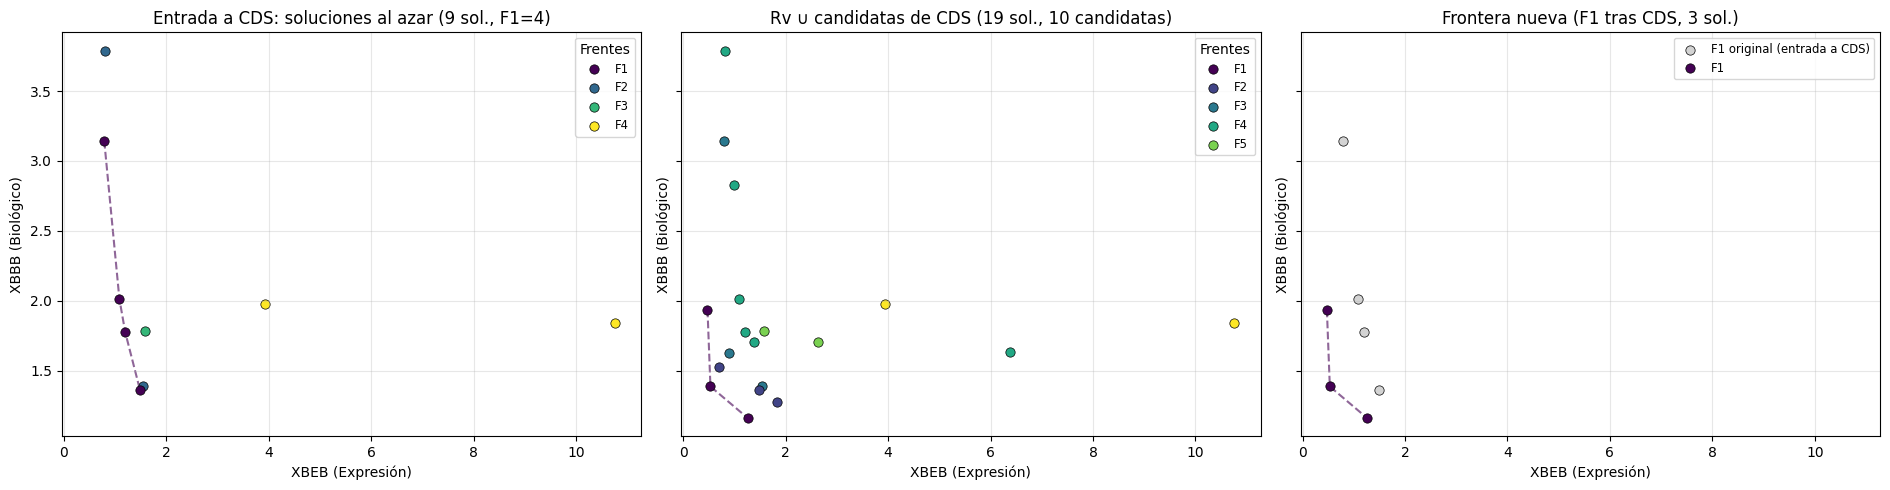

In [7]:
##################################
# Bloque de ejecución/testeo: Consensus Divergence Search (CDS)
# (población al azar como Rv; CDS recibe su F1 COMPLETO, ya que la matriz
# de co-asociación se construye a partir de todo el frente, y sus
# candidatas se fusionan con Rv antes de decidir supervivencia)
##################################
K         = 4
POP_SIZE  = 9
SEED      = None

ge_matrix, gene_names = load_distance_matrix(DE_DIR)
bi_matrix, _           = load_distance_matrix(DB_DIR)
n = ge_matrix.shape[0]

solution_encoding.OBJ_FUNCTION_CALLS = 0

test_solutions_cds = random_medoids_pop(n=n, k=K, pop_size=POP_SIZE, seed=SEED)
test_labels_cds = build_clusters_population(ge_matrix, test_solutions_cds)
test_objectives_cds = np.array([evaluate_objectives(C, ge_matrix, bi_matrix) for C in test_solutions_cds])

entrada_fronts_cds = non_dominated_sort(test_objectives_cds)
f1_idx_cds = entrada_fronts_cds[0]
f1_solutions_cds = test_solutions_cds[f1_idx_cds]
f1_labels_cds = test_labels_cds[f1_idx_cds]
f1_objectives_cds = test_objectives_cds[f1_idx_cds]

print(f"n genes = {n}  |  k medoides = {K}\n")
print(f"Soluciones al azar generadas (Rv): {len(test_solutions_cds)}")
print(f"F1 de la población (entrada a CDS): {len(f1_solutions_cds)}\n")

candidatas_cds = consensus_divergence_search(
    f1_solutions_cds, f1_labels_cds, ge_matrix, bi_matrix, verbose=True,
)

print(f"\nCandidatas generadas (mejoran al menos un objetivo): {len(candidatas_cds)}")
for j, d in enumerate(candidatas_cds):
    genes = [gene_names[g] for g in d["solution"]]
    print(f"── Candidata {j}: {genes} ──  XBEB={d['xb_eb']:.6f}  XBBB={d['xb_bb']:.6f}")

print(f"\nLlamadas a función objetivo consumidas: {solution_encoding.OBJ_FUNCTION_CALLS}")

##################################
# Gráficos: (1) Rv de entrada (con su F1 destacado), (2) Rv fusionado con
# las candidatas de CDS (la supervivencia la decide non_dominated_sort) y
# (3) la frontera NUEVA aislada, comparada con el F1 original de entrada
##################################
cand_objectives_cds = (
    np.array([[d["xb_eb"], d["xb_bb"]] for d in candidatas_cds])
    if candidatas_cds else np.empty((0, 2))
)
rv_objectives_cds = np.vstack([test_objectives_cds, cand_objectives_cds])
rv_fronts_cds = non_dominated_sort(rv_objectives_cds)
nueva_frontera_idx_cds = rv_fronts_cds[0]

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharex=True, sharey=True)
plot_pareto_fronts_note(
    test_objectives_cds, entrada_fronts_cds,
    title=f"Entrada a CDS: soluciones al azar ({len(test_solutions_cds)} sol., F1={len(f1_solutions_cds)})",
    ax=axes[0],
)
plot_pareto_fronts_note(
    rv_objectives_cds, rv_fronts_cds,
    title=f"Rv ∪ candidatas de CDS ({rv_objectives_cds.shape[0]} sol., "
          f"{len(candidatas_cds)} candidatas)",
    ax=axes[1],
)
axes[2].scatter(
    f1_objectives_cds[:, 0], f1_objectives_cds[:, 1],
    color="lightgray", s=45, edgecolors="black", linewidths=0.5,
    label="F1 original (entrada a CDS)", zorder=1,
)
plot_pareto_fronts_note(
    rv_objectives_cds, [nueva_frontera_idx_cds],
    title=f"Frontera nueva (F1 tras CDS, {len(nueva_frontera_idx_cds)} sol.)",
    ax=axes[2],
)
axes[2].legend(loc="best", fontsize="small")

fig.tight_layout()
plt.show()
